In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import json
import seaborn as sns

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model")


##  Results Selection

In [3]:
# model paramters
Result_dict = {
'project_name': "Italy",
'year': 2040,
'sceanrio': "GA",
'FLEX': True,
'NTC': True,
'H2': False,
'Synthetic_fuels': False
}

In [4]:
RESULT_DIR = os.path.join(
    PROJECT_DIR,
    Result_dict['project_name'],
    Result_dict['sceanrio'],
    str(Result_dict['year'])
)
print(f"RESULT_DIR: {RESULT_DIR}")

RESULT_DIR: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/Italy/GA/2040


## Time series introduction

In [5]:
# Recalculate prefix
prefix_results = f"FLEX_{Result_dict['FLEX']}_NTC_{Result_dict['NTC']}_H2_{Result_dict['H2']}_Syn_{Result_dict['Synthetic_fuels']}"

# Updated path: include project, scenario, AND year (str)
results_path = os.path.join(PROJECT_DIR, 'results', Result_dict['project_name'], Result_dict['sceanrio'], str(Result_dict['year']))
timeseries_filename = f"{prefix_results}_time_series_results.csv"
timeseries_full_path = os.path.join(results_path, timeseries_filename)

# Import the data
if os.path.exists(timeseries_full_path):
    results = pd.read_csv(timeseries_full_path, index_col=0, parse_dates=True)
    print(f"✅ Successfully imported time series data from: {timeseries_filename}")
    display(results.head(3))
else:
    print(f"❌ File still not found at: {timeseries_full_path}")
    if os.path.exists(results_path):
        print(f"Contents of the final folder: {os.listdir(results_path)}")
    else:
        print(f"Directory does not exist: {results_path}")

✅ Successfully imported time series data from: FLEX_True_NTC_True_H2_False_Syn_False_time_series_results.csv


,gen_p_Global_Coal_Import,gen_p_AT00_Gas_Source,gen_p_AT00_Nuclear_Plant,gen_p_AT00_RES_plant,gen_p_ITSI_Gas_Source,gen_p_ITSI_RES_plant,gen_p_ITSA_Gas_Source,gen_p_ITSA_RES_plant,gen_p_ITCA_Gas_Source,gen_p_ITCA_RES_plant,...,marginal_price_ITS1_electricity_market,marginal_price_ITS1_gas_bus,marginal_price_ITCS_electricity_market,marginal_price_ITCS_gas_bus,marginal_price_ITCN_electricity_market,marginal_price_ITCN_gas_bus,marginal_price_ITN1_electricity_market,marginal_price_ITN1_gas_bus,marginal_price_SI00_electricity_market,marginal_price_SI00_gas_bus
snapshot,,,,,,,,,,,,,,,,,,,,,
2040-01-01 00:00:00,-0.0,-0.0,-0.0,4052.803001,-0.0,2009.0000,-0.0,2009.0000,-0.0,2009.000,...,4.6,40.0,4.6,40.0,4.842105,40.0,5.096953,40.0,5.365214,40.0
2040-01-01 01:00:00,-0.0,-0.0,-0.0,4100.621813,-0.0,893.5234,-0.0,767.4366,-0.0,295.218,...,4.6,40.0,4.6,40.0,4.842105,40.0,5.096953,40.0,5.395062,40.0
2040-01-01 02:00:00,-0.0,-0.0,-0.0,3982.951088,-0.0,837.1671,-0.0,740.1678,-0.0,268.807,...,4.6,40.0,4.6,40.0,4.842105,40.0,5.096953,40.0,5.395062,40.0


### Slach Generators

Supply Deficits per Zone (GWh/year):


carrier,electricity,natural_gas
zone,,
AT00,0.0,0.0
EU,0.0,0.0
ITCA,0.0,0.0
ITCN,0.0,0.0
ITCS,0.0,0.0
ITN1,0.0,0.0
ITS1,0.0,0.0
ITSA,0.0,0.0
ITSI,0.0,0.0


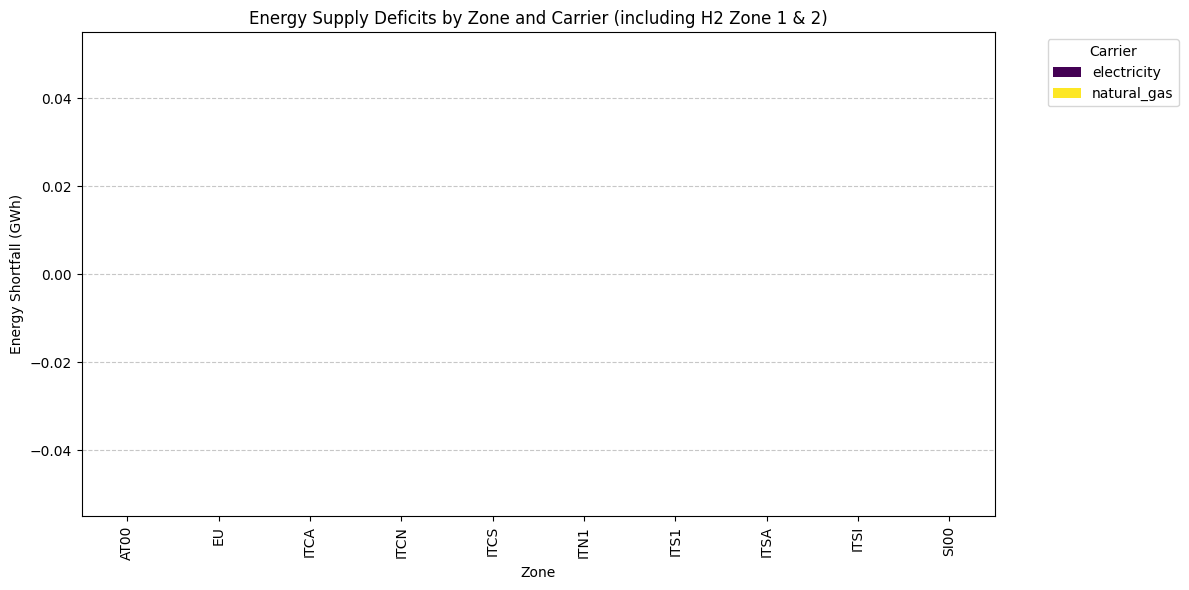

In [6]:
# 1. Identify slack generator columns in the results
slack_cols = [c for c in results.columns if 'slack' in c.lower() or 'deficit' in c.lower()]

if slack_cols:
    # Sum the slack usage over the year (converting to GWh if data is in MWh)
    deficits = results[slack_cols].sum() / 1e3

    # Create a clean DataFrame for plotting
    deficit_df = deficits.reset_index()
    deficit_df.columns = ['component', 'GWh']

    # Extract zone and carrier from the column names
    # Expected format: gen_p_ZONE_CARRIER_slack or similar
    deficit_df['zone'] = deficit_df['component'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'Other')
    deficit_df['carrier_raw'] = deficit_df['component'].apply(lambda x: x.split('_')[3].lower() if len(x.split('_')) > 3 else 'unknown')

    # Logic to handle H2 Zone 1 vs Zone 2
    def map_carrier(row):
        raw = row['carrier_raw']
        comp = row['component'].lower()
        if 'h2' in raw or 'hydrogen' in raw:
            if 'z1' in comp or 'zone1' in comp:
                return 'hydrogen_zone1'
            if 'z2' in comp or 'zone2' in comp:
                return 'hydrogen_zone2'
            return 'hydrogen'
        if 'elec' in raw:
            return 'electricity'
        if 'gas' in raw:
            return 'natural_gas'
        return raw

    deficit_df['carrier'] = deficit_df.apply(map_carrier, axis=1)

    # Aggregate duplicates before pivoting
    zonal_deficits_agg = deficit_df.groupby(['zone', 'carrier'])['GWh'].sum().reset_index()
    zonal_deficits = zonal_deficits_agg.pivot(index='zone', columns='carrier', values='GWh').fillna(0)

    # Remove 'coal' if it exists and has 0 values, or ensure it's not explicitly added
    if 'coal' in zonal_deficits.columns and zonal_deficits['coal'].sum() == 0:
        zonal_deficits = zonal_deficits.drop(columns=['coal'])

    print("Supply Deficits per Zone (GWh/year):")
    display(zonal_deficits)

    # 2. Visualize
    zonal_deficits.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
    plt.title("Energy Supply Deficits by Zone and Carrier (including H2 Zone 1 & 2)")
    plt.ylabel("Energy Shortfall (GWh)")
    plt.xlabel("Zone")
    plt.legend(title="Carrier", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No slack generator columns found in the results.")

### Pricing

Average Annual Marginal Prices per Zone:


Carrier,Electricity,Natural Gas,coal_market
Zone,,,
AT00,4.96,40.0,-
EU,-,40.0,25.0
ITCA,4.67,40.0,-
ITCN,5.03,40.0,-
ITCS,4.89,40.0,-
ITN1,5.33,40.0,-
ITS1,4.73,40.0,-
ITSA,4.75,40.0,-
ITSI,4.69,40.0,-


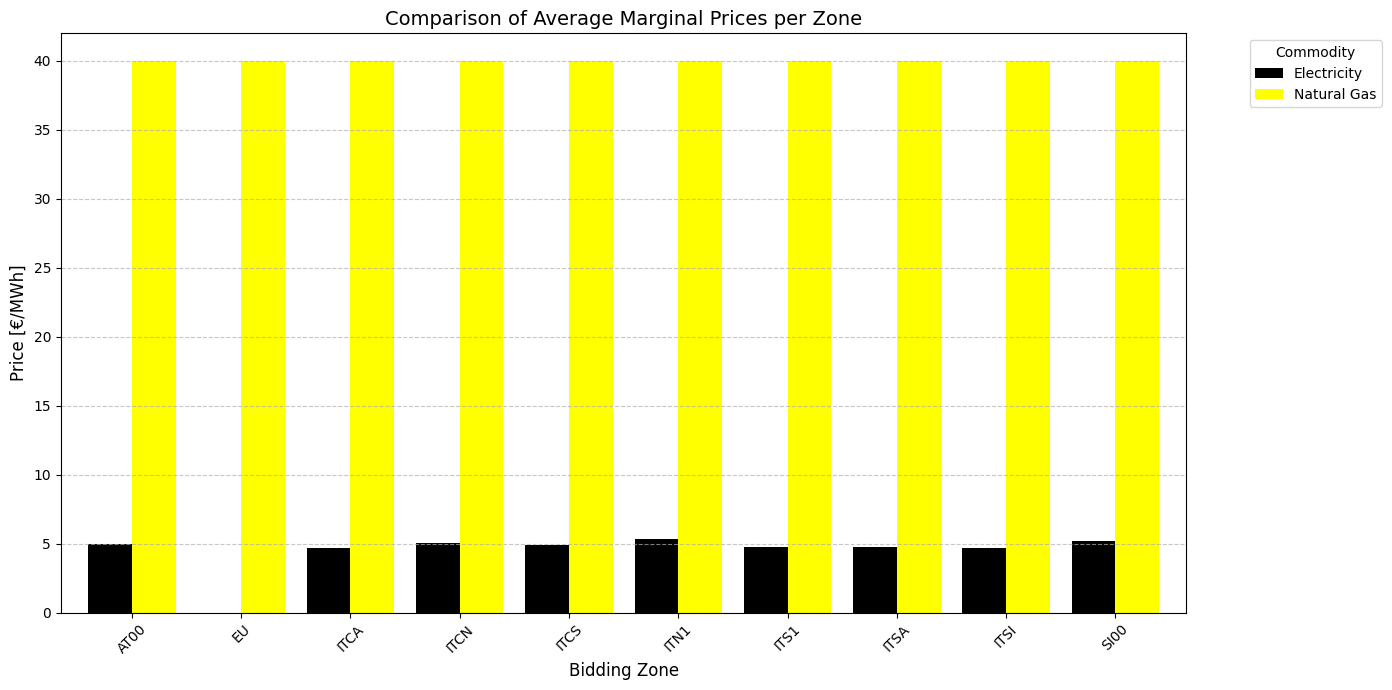

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter marginal price columns and calculate averages
price_cols = [c for c in results.columns if 'marginal_price_' in c]
prices = results[price_cols].mean()

price_data = []
for col, avg_price in prices.items():
    parts = col.replace('marginal_price_', '').split('_')
    if len(parts) >= 2:
        zone = parts[0]
        carrier_raw = '_'.join(parts[1:])

        if 'elec' in carrier_raw:
            carrier = 'Electricity'
        elif 'gas' in carrier_raw:
            carrier = 'Natural Gas'
        elif 'h2' in carrier_raw or 'hydrogen' in carrier_raw:
            carrier = 'Hydrogen'
        else:
            carrier = carrier_raw

        price_data.append({'Zone': zone, 'Carrier': carrier, 'Price': avg_price})

df_prices = pd.DataFrame(price_data)

# 2. Create Table View
price_pivot = df_prices.pivot(index='Zone', columns='Carrier', values='Price')

# Ensure Natural Gas is 40 if present (as per user request)
if 'Natural Gas' in price_pivot.columns:
    price_pivot['Natural Gas'] = 40.0

print("Average Annual Marginal Prices per Zone:")
display(price_pivot.round(2).fillna('-'))

# 3. Create Graph View with requested colors
if not price_pivot.empty:
    main_commodities = ['Electricity', 'Natural Gas', 'Hydrogen']
    available_cols = [c for c in main_commodities if c in price_pivot.columns]
    graph_data = price_pivot[available_cols].fillna(0)

    # Updated Color map: Natural Gas to yellow
    color_map = {'Electricity': 'black', 'Natural Gas': 'yellow', 'Hydrogen': '#32CD32'}
    plot_colors = [color_map.get(c, 'gray') for c in graph_data.columns]

    ax = graph_data.plot(kind='bar', figsize=(14, 7), width=0.8, color=plot_colors)
    plt.title("Comparison of Average Marginal Prices per Zone", fontsize=14)
    plt.ylabel("Price [€/MWh]", fontsize=12)
    plt.xlabel("Bidding Zone", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Commodity", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Zone Results

### NTC electricity and hydrogen

### Pricing, Demand and Production

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Using the 'results' DataFrame instead of the network object
# Identify H2-related marginal price columns
h2_price_cols = [c for c in results.columns if 'marginal_price_' in c and ('h2' in c.lower() or 'hydrogen' in c.lower())]

if h2_price_cols:
    h2_avg_prices = results[h2_price_cols].mean()
    h2_diagnostic_df = h2_avg_prices.reset_index()
    h2_diagnostic_df.columns = ['Bus', 'Avg Price']
    print("Hydrogen Price Diagnostics (from DataFrame):")
    display(h2_diagnostic_df)
else:
    print("No Hydrogen price columns found in the results DataFrame.")

No Hydrogen price columns found in the results DataFrame.


### Technologies - Electrolysers and SMR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check Electrolyzer Utilization from results DataFrame
# Electrolyzers are typically links: link_p0 (input) or link_p1 (output)
ely_cols = [c for c in results.columns if 'Electrolyser' in c and 'link_p0' in c]

if ely_cols:
    print("--- Electrolyzer Utilization Analysis ---")
    # Note: Without p_nom from the network object, we analyze absolute usage levels
    ely_usage = results[ely_cols].mean().sort_values(ascending=False)
    display(ely_usage.to_frame('Mean Hourly Power Intake (MW)'))
else:
    print("No electrolyzer columns found in the results DataFrame.")

# 2. Check Pipeline Flows from results DataFrame
pipe_cols = [c for c in results.columns if 'H2_Pipe' in c and 'link_p0' in c]
if pipe_cols:
    print("\n--- H2 Pipeline Flow Analysis ---")
    pipe_flows = results[pipe_cols].sum() / 1e3 # GWh
    display(pipe_flows.to_frame('Total Annual Flow (GWh)'))
else:
    print("No hydrogen pipeline columns found in the results DataFrame.")

No electrolyzer columns found in the results DataFrame.
No hydrogen pipeline columns found in the results DataFrame.
